In [1]:
#Importing Libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,  ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier




import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv


In [2]:
#Loading the Dataset
df=pd.read_csv("/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv")

**Data Exploration**

In [3]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [4]:
#Checking the shape of the data
df.shape

(205052, 6)

The dataset contains 205052 rows and 6 columns.

In [5]:
#Checking the data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [6]:
#Checking the dataset columns
df.columns.tolist()

['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']

In [7]:
#Checking for the dataset description
df.describe()

,product_name,product_price,Rate,Review,Summary,Sentiment
count,205052,205052,205052,180388,205041,205052
unique,958,525,8,1324,92923,3
top,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,wonderful,good,positive
freq,6005,9150,118765,9016,17430,166581


In [8]:
#Check for sentiment balance
df["Sentiment"].value_counts()

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

In [9]:
#Checking for Sentiment balance in percentage
df["Sentiment"].value_counts()/len(df["Sentiment"])*100



Sentiment
positive    81.238418
negative    13.768215
neutral      4.993368
Name: count, dtype: float64

The result above shows that positive as the highest sentiment class and Neutral as the lowest sentiment class

In [10]:
#Drop neutral for a cleaner analysis as it acts as a background noise
df=df[df["Sentiment"]!="neutral"]

In [11]:
df["Sentiment"].value_counts()

Sentiment
positive    166581
negative     28232
Name: count, dtype: int64

In [12]:
#Checking for Missing values
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           23236
Summary              6
Sentiment            0
dtype: int64

In [13]:
#Drop Missing Value
df.dropna(subset=["Review","Summary"],inplace=True)

In [14]:
df.isnull().sum()

product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64

In [15]:
#Check for duplicates
df.duplicated().any()

np.True_

In [16]:
df.duplicated().sum()

np.int64(25411)

In [17]:
df.drop_duplicates(keep="first")

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
5,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,the cooler is really fantastic and provides go...,positive
...,...,...,...,...,...,...
205044,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,wonderful,superb,positive
205045,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,terrific,good quality products,positive
205046,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,classy product,beautiful set very nice,positive
205049,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,3,nice,very nice and fast delivery,positive


In [18]:
df.shape

(171572, 6)

After cleaning, the number of rows now stands at 171572

In [19]:
#Combining Review and Summary Columns as they are the primary feature
df["combined_text"]=df["Review"]+" "+ df["Summary"]


In [20]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment,combined_text
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive,super! great cooler excellent air flow and for...
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive,awesome best budget 2 fit cooler nice cooling
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive,fair the quality is good but the power of air ...
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative,useless product very bad product its a only a fan
5,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,the cooler is really fantastic and provides go...,positive,awesome the cooler is really fantastic and pro...


In [21]:
#Drop columns that do not affect the analysis
df.drop(columns=["product_name","product_price","Review","Summary"],axis=1,inplace=True)

In [22]:
df.head()

,Rate,Sentiment,combined_text
0,5,positive,super! great cooler excellent air flow and for...
1,5,positive,awesome best budget 2 fit cooler nice cooling
2,3,positive,fair the quality is good but the power of air ...
3,1,negative,useless product very bad product its a only a fan
5,5,positive,awesome the cooler is really fantastic and pro...


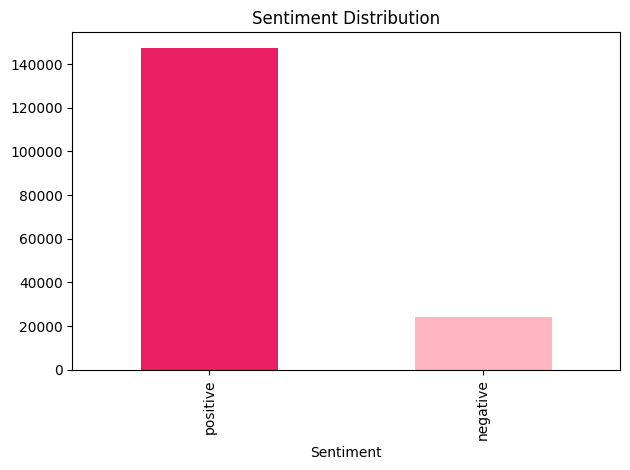

In [23]:
#Visualize Sentiment Distribution
df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["#E91E63","#FFB6C1"],
    title="Sentiment Distribution"
)
plt.xlabel="Sentiment"
plt.ylable="Counts"
plt.tight_layout()
plt.show()

**Text Preprocessing**

In [24]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [25]:
#Applying prepocessing function
def preprocess(text):
    text=text.lower() #Convert to lowercase
    text=re.sub(r"[^a-zA-Z]\s"," ",text)
    tokens=word_tokenize(text)
    tokens=[lemmatizer.lemmatize(t) for t in tokens
            if t not in stop_words and len(t)>2]
    return " ".join(tokens)
    
df["cleaned_text"]=df["combined_text"].apply(preprocess)
pos_words=" ".join(df[df.Sentiment=="positive"]["cleaned_text"])
neg_words=" ".join(df[df.Sentiment=="negative"]["cleaned_text"])

print(f"Positive(First 50):{pos_words[:50]} \nNegative(First 50):{neg_words[:50]}")

Positive(First 50):super great cooler excellent air flow price amazin 
Negative(First 50):useless product bad product fan unsatisfactory bad


In [26]:
#Splitting data using Counter
pos_split=Counter(pos_words.split()).most_common(10)
neg_split=Counter(neg_words.split()).most_common(10)

In [27]:
print(f"Top 10 Positive Words: {pos_split}")

Top 10 Positive Words: [('good', 82494), ('product', 74717), ('nice', 42214), ('quality', 18817), ('awesome', 17982), ('best', 15629), ('super', 12432), ('purchase', 12045), ('worth', 11814), ('excellent', 10859)]


In [28]:
print(f"Top 10 Negative Words: {neg_split}")

Top 10 Negative Words: [('product', 11274), ('bad', 6030), ('quality', 5790), ('good', 5753), ('money', 4338), ('waste', 4126), ('worst', 3372), ('poor', 3247), ('dont', 2754), ('buy', 2629)]


**Data Visualization**

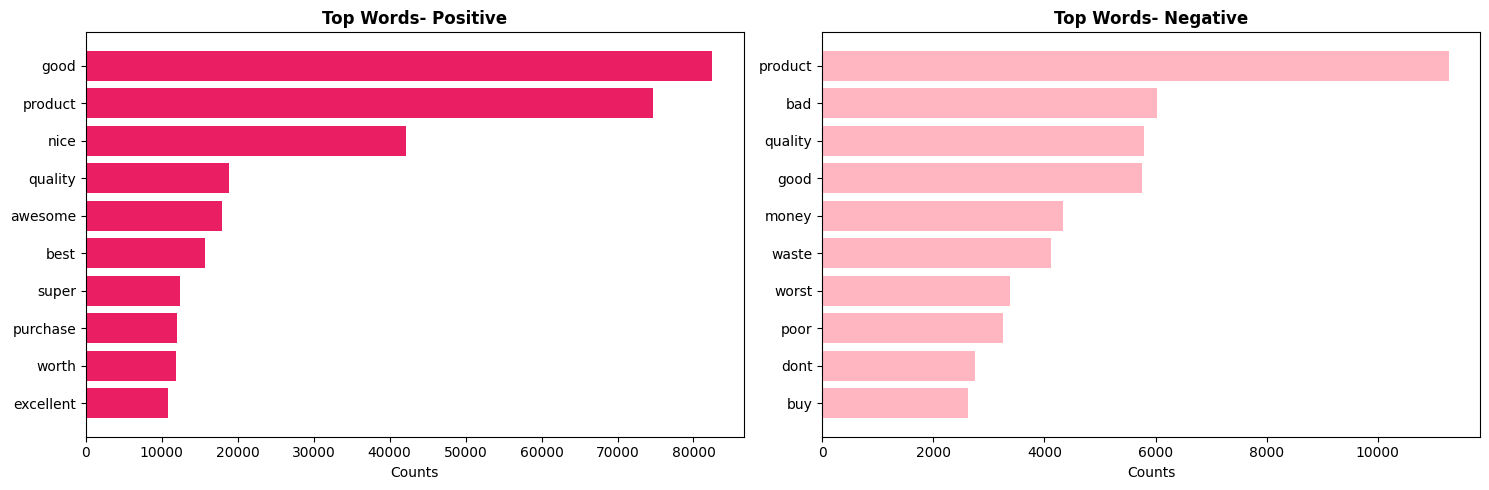

In [29]:
#Visualizing the Top words in each Sentiment
fig,axes=plt.subplots(1,2,figsize=(15,5))
data=[pos_split,neg_split]
color=["#E91E63","#FFB6C1"]
label=["Positive","Negative"]

for ax,dt,col,lbl in zip(axes,data,color,label):
  w,c=zip(*dt)
  ax.barh(list(w)[::-1],list(c)[::-1],color=col)
  ax.set_title(f"Top Words- {lbl}",fontweight="bold")
  ax.set_xlabel("Counts")

plt.tight_layout()
plt.show()

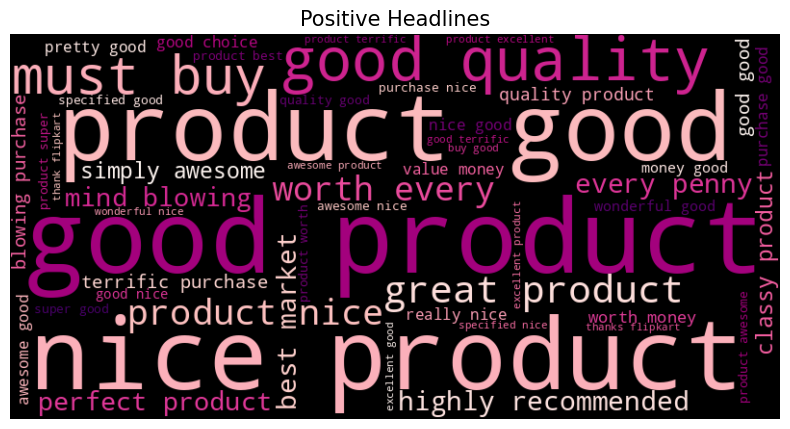

In [30]:
#Applying Word Cloud to Positive Words
pos_corpus = ' '.join(df[df['Sentiment'] == 'positive']['cleaned_text'])

    # Create word cloud
wc = WordCloud(
        width            = 800,
        height           = 400,
        background_color = 'black',
        colormap         = 'RdPu',    # pink gradient
        max_words        = 50,
        min_font_size    = 10,
        contour_width    = 1,
        contour_color    = color
    ).generate(pos_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.title('Positive Headlines', fontsize=15)
plt.axis('off') # Hide the x and y axis numbers
plt.show()

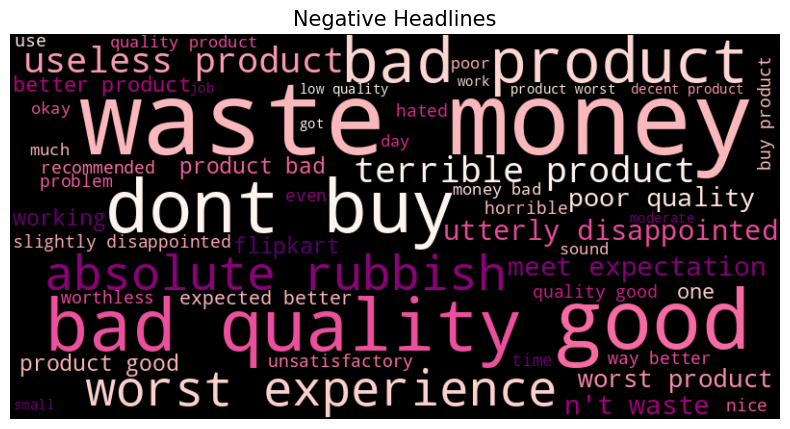

In [31]:
#Applying Word Cloud to Negative Words
neg_corpus = ' '.join(df[df['Sentiment'] == 'negative']['cleaned_text'])

    # Create word cloud
wc = WordCloud(
        width            = 800,
        height           = 400,
        background_color = 'black',
        colormap         = 'RdPu',    # pink gradient
        max_words        = 50,
        min_font_size    = 10,
        contour_width    = 1,
        contour_color    = color
    ).generate(neg_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.title('Negative Headlines', fontsize=15)
plt.axis('off') # Hide the x and y axis numbers
plt.show()

In [32]:
df.head()

,Rate,Sentiment,combined_text,cleaned_text
0,5,positive,super! great cooler excellent air flow and for...,super great cooler excellent air flow price am...
1,5,positive,awesome best budget 2 fit cooler nice cooling,awesome best budget fit cooler nice cooling
2,3,positive,fair the quality is good but the power of air ...,fair quality good power air decent
3,1,negative,useless product very bad product its a only a fan,useless product bad product fan
5,5,positive,awesome the cooler is really fantastic and pro...,awesome cooler really fantastic provides good ...


In [33]:
#Mapping Sentiment with Labels
sentiment_map={"positive":1,"negative":0}

df["Sentiment_Label"]=df["Sentiment"].map(sentiment_map)

print(df[["Sentiment","Sentiment_Label"]].head())

  Sentiment  Sentiment_Label
0  positive                1
1  positive                1
2  positive                1
3  negative                0
5  positive                1


**Feature Engineering**

In [34]:
#Features and Labels
X=df["cleaned_text"]
y=df["Sentiment_Label"]

In [35]:
#Splitting Data into 80/20
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [36]:
#Create and fit TF-IDF (ONLY fit on training data!)
tfidf = TfidfVectorizer(
    max_features = 500,       # top 500 words only
    ngram_range  = (1, 2),   # unigrams and bigrams
    min_df       = 2          # ignore very rare words
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)   # NO fit here!

print(f"Train: {X_train_tfidf.shape}")
print(f"Test:  {X_test_tfidf.shape}")


Train: (137257, 500)
Test:  (34315, 500)


**Model Training and Prediction**

In [37]:
# Train model using Logistic Regression
clf = LogisticRegression(
    max_iter     = 1000,
    C            = 1.0,      # regularisation (lower = simpler)
    random_state = 42
)
clf.fit(X_train_tfidf, y_train)

rf_train = clf.score(X_train_tfidf, y_train)
rf_test  = clf.score(X_test_tfidf,  y_test)

print(f"LR  Train:{rf_train:.2%}  Test:{rf_test:.2%}")





LR  Train:96.67%  Test:96.44%


In [38]:
#Predict Accuracy of Model

# Predict
y_pred = clf.predict(X_test_tfidf)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2%}")

# Full report
print(classification_report(
    y_test, y_pred,
    target_names=['Negative','Positive']
))

Test Accuracy: 96.44%
              precision    recall  f1-score   support

    Negative       0.91      0.84      0.87      4880
    Positive       0.97      0.99      0.98     29435

    accuracy                           0.96     34315
   macro avg       0.94      0.91      0.92     34315
weighted avg       0.96      0.96      0.96     34315



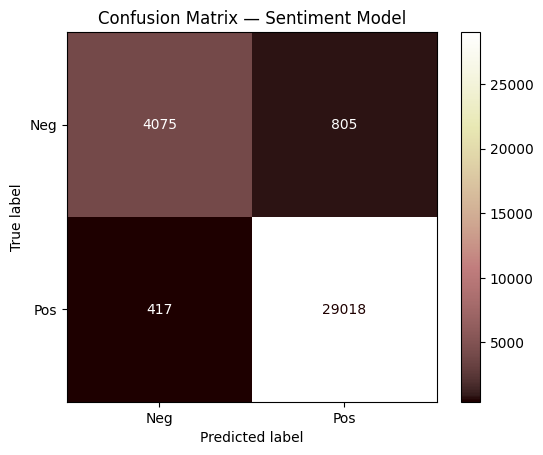

In [39]:
# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm,
         display_labels=['Neg','Pos'])
disp.plot(cmap='pink')
plt.title("Confusion Matrix — Sentiment Model")
plt.show()


In [40]:
#Train Model Using Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    oob_score=True,
    max_depth=4,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)

rf_train = rf.score(X_train_tfidf, y_train)
rf_test  = rf.score(X_test_tfidf,  y_test)

print(f"RF  Train:{rf_train:.2%}  Test:{rf_test:.2%}")
print(f"RF  OOB:  {rf.oob_score_:.2%}")




RF  Train:95.35%  Test:95.01%
RF  OOB:  93.66%


In [41]:
#Predict Accuracy of Model

#Predict
y_pred=rf.predict(X_test_tfidf)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2%}")

#Full Report
for name, mdl in [("RF",rf)]:
    print(f"\n--- {name} Report ---")
    print(classification_report(
        y_test, y_pred,
        target_names=['Negative','Positive']))

Test Accuracy: 95.01%

--- RF Report ---
              precision    recall  f1-score   support

    Negative       0.85      0.78      0.82      4880
    Positive       0.96      0.98      0.97     29435

    accuracy                           0.95     34315
   macro avg       0.91      0.88      0.89     34315
weighted avg       0.95      0.95      0.95     34315



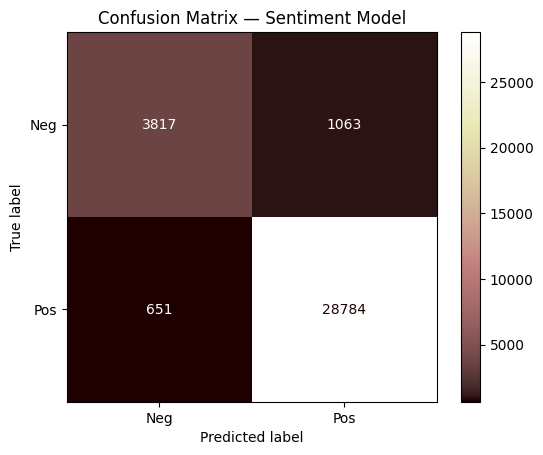

In [42]:
# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm,
         display_labels=['Neg','Pos'])
disp.plot(cmap='pink')
plt.title("Confusion Matrix — Sentiment Model")
plt.show()


**Comparing both Models**


**Logistic Regression Model outperforms Random Forest Model.Logistic Regression Model predicted an accuracy score of 96.44% on the test data.Random Forest Model predicted an accuracy score of 95.01%.**

